# Exploratory Data analysis

Exploratory Data analysis of the time series of new york monthly waste tons collected  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

df_processed = pd.read_csv('../data/processed/dsny_cleaned.csv')


### Visual analysis

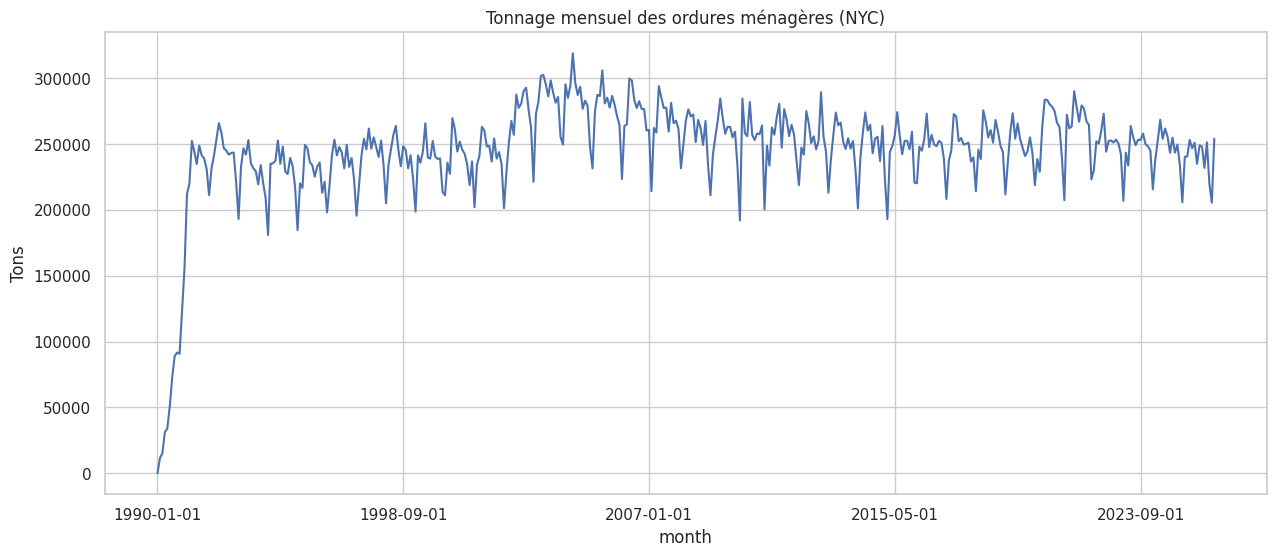

In [4]:
# Tracer la série temporelle totale par mois
df_agg = df_processed.groupby('month')['refusetonscollected'].sum()
plt.figure(figsize=(15, 6))
df_agg.plot(title="Tonnage mensuel des ordures ménagères (NYC)")
plt.ylabel("Tons")
plt.show()

### Seasonal decomposition

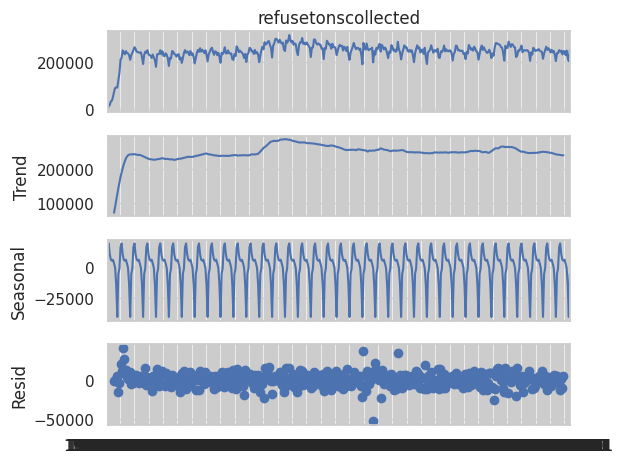

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assure-toi que la série est bien indexée par date
result = seasonal_decompose(df_agg, model='additive', period=12)
result.plot()
plt.show()

### Time correlation analysis

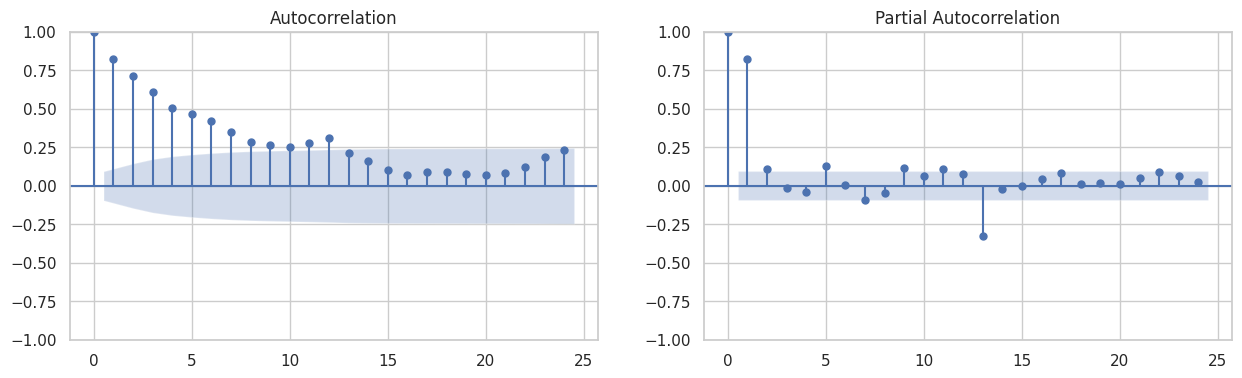

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df_agg, lags=24, ax=ax[0])
plot_pacf(df_agg, lags=24, ax=ax[1])
plt.show()

### Per Borough analysis

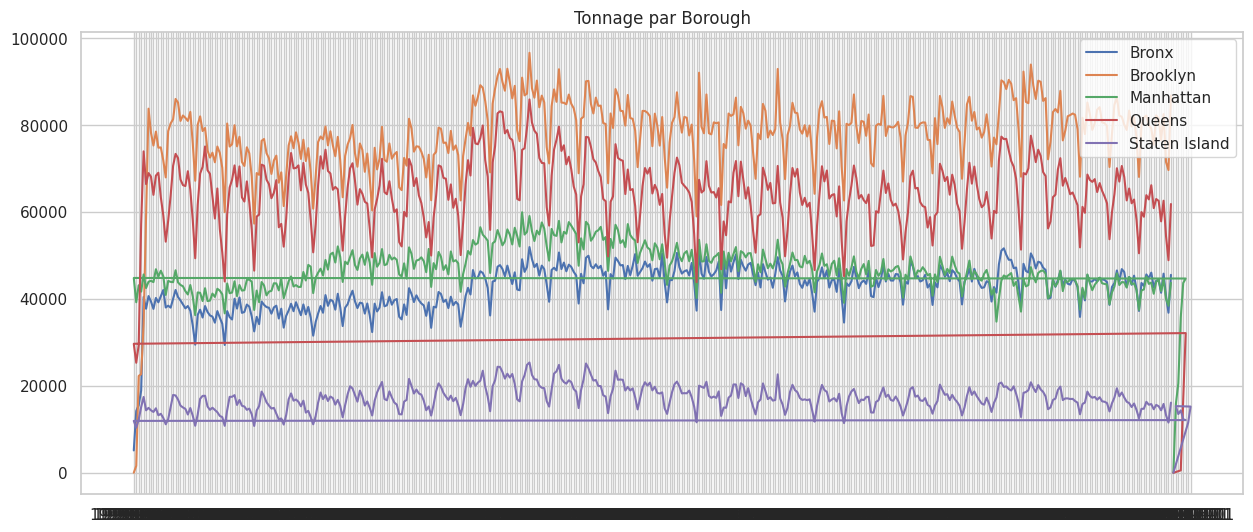

In [7]:
# Comparaison par borough
plt.figure(figsize=(15, 6))
for borough in df_processed['borough'].unique():
    subset = df_processed[df_processed['borough'] == borough].groupby('month')['refusetonscollected'].sum()
    plt.plot(subset.index, subset.values, label=borough)
plt.legend()
plt.title("Tonnage par Borough")
plt.show()

### Stationnaity test

In [8]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Résultats du test Augmented Dickey-Fuller :")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)

test_stationarity(df_agg)

Résultats du test Augmented Dickey-Fuller :
Test Statistic                  -3.198772
p-value                          0.020056
#Lags Used                      15.000000
Number of Observations Used    415.000000
Critical Value (1%)             -3.446206
Critical Value (5%)             -2.868530
Critical Value (10%)            -2.570493
dtype: float64


### Normality test

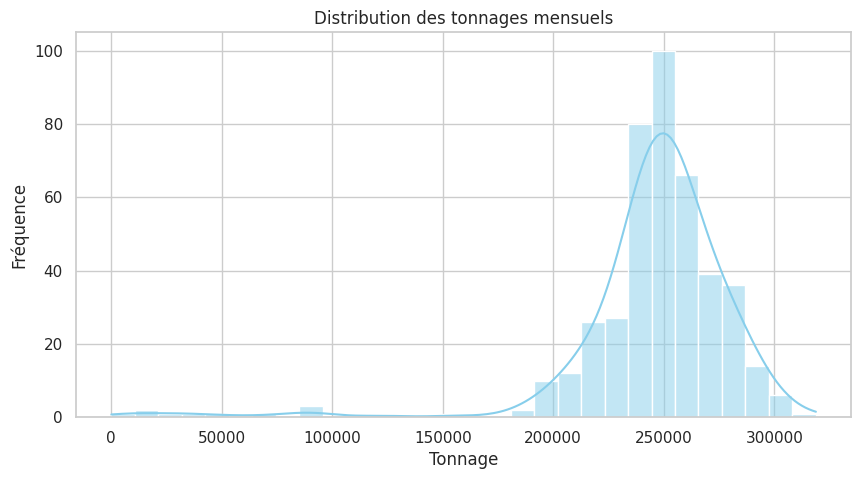

Statistique=0.704, p-value=0.000


In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_agg, kde=True, bins=30, color='skyblue')
plt.title("Distribution des tonnages mensuels")
plt.xlabel("Tonnage")
plt.ylabel("Fréquence")
plt.show()

# Test rapide de normalité (Shapiro-Wilk)
from scipy.stats import shapiro
stat, p = shapiro(df_agg)
print(f'Statistique={stat:.3f}, p-value={p:.3f}')

## Conclusion de l'Analyse Exploratoire

Cette phase d'exploration nous a permis de valider la faisabilité technique du projet de prévision des tonnages de déchets à New York. L'analyse statistique a mis en lumière deux caractéristiques majeures de notre cible, refusetonscollected :

    Stationnarité confirmée : Le test ADF a révélé une p-value de 0.02, confirmant que notre série est stationnaire. Cela simplifie grandement la modélisation, nous évitant des étapes de différenciation complexes et nous permettant de modéliser la série directement.

    Distribution non-normale : Le test de Shapiro-Wilk (p-value=0.000) confirme une distribution asymétrique, typique des données de déchets qui présentent des pics liés à des événements ponctuels.

Impact pour la suite :
Ces résultats dictent notre stratégie de modélisation : puisque nous traitons une série stationnaire mais non-normale, nous privilégierons des modèles robustes, capables de capturer des non-linéarités (type Random Forest ou Gradient Boosting) plutôt que des modèles linéaires classiques. La prochaine étape consistera à enrichir notre jeu de données avec des features temporelles (lags, saisonnalité) pour entraîner notre premier modèle de prévision.